# 04 – Random Forest Forecasting Model

## Objective

This notebook develops a Random Forest regression model to forecast the weekly EUR/USD closing exchange rate. Unlike the ARIMA model, Random Forest can learn complex nonlinear relationships by utilizing multiple engineered features such as lag values, moving averages, and rolling volatility.

The forecasting performance of the Random Forest model will be evaluated using the same train-test split and evaluation metrics as the ARIMA model to ensure a fair comparison.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv(
    "../data/processed/eur_weekly_model_ready_v2.csv",
    parse_dates=["Date"]
)

## Preparing Features and Target Variable

Machine learning models require the predictor variables (features) to be separated from the variable to be predicted (target).

In this study, the weekly EUR/USD closing exchange rate (`Price`) is selected as the prediction target, while all remaining numerical variables are used as explanatory features.

The `Date` column is excluded because Random Forest cannot directly learn from datetime values.

In [3]:
# Target variable
y = df["Target"]

# Feature variables
X = df.drop(columns=["Date", "Price", "Target"])

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Open', 'High', 'Low', 'Change %', 'Lag_1', 'Lag_2', 'Lag_3', 'MA_5', 'MA_10', 'MA_20', 'Volatility_5']

Target:
Target


## Chronological Train-Test Split

The dataset is divided chronologically into training and testing subsets. The first 80% of the observations are used for model training, while the remaining 20% are reserved for out-of-sample evaluation.

Unlike random sampling, chronological splitting preserves the temporal ordering of observations and prevents future information from leaking into the training process. This approach reflects real-world forecasting conditions.

In [4]:
# 80% training data
train_size = int(len(df) * 0.80)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Training observations:", len(X_train))
print("Testing observations :", len(X_test))

print("\nTraining period:")
print(df["Date"].iloc[0], "to", df["Date"].iloc[train_size-1])

print("\nTesting period:")
print(df["Date"].iloc[train_size], "to", df["Date"].iloc[-1])

Training observations: 1064
Testing observations : 267

Training period:
2000-10-01 00:00:00 to 2021-02-14 00:00:00

Testing period:
2021-02-21 00:00:00 to 2026-03-29 00:00:00


## Training the Random Forest Model

Random Forest is an ensemble learning algorithm that combines the predictions of multiple decision trees. Each tree is trained on a random subset of the training observations and predictor variables.

By averaging the predictions from many trees, Random Forest reduces overfitting and improves predictive performance. The model is trained using the engineered lag variables, moving averages, volatility measure, and other market variables created during preprocessing.

In [5]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Forecasting the Test Dataset

After training, the Random Forest model is used to predict the EUR/USD closing exchange rate for the testing period.

These forecasts are generated using only information available during training, ensuring that the evaluation reflects realistic forecasting conditions.

In [6]:
predictions = rf_model.predict(X_test)

predictions = pd.Series(
    predictions,
    index=y_test.index
)

predictions.head()

1064    1.224222
1065    1.215791
1066    1.194760
1067    1.190980
1068    1.193898
dtype: float64

## Random Forest Forecast versus Actual Values

The forecasting performance of the Random Forest model is visualized by comparing the predicted EUR/USD closing exchange rates with the actual observations in the testing period.

A close alignment between the two series indicates that the model successfully captures the underlying movement of the exchange rate.

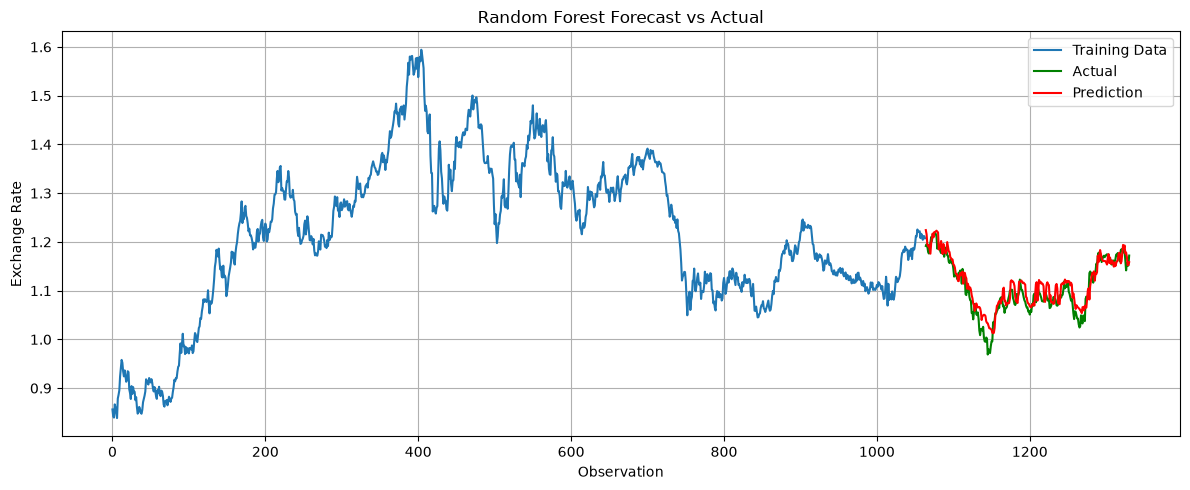

In [7]:
plt.figure(figsize=(12,5))

plt.plot(y_train.index, y_train, label="Training Data")
plt.plot(y_test.index, y_test, label="Actual", color="green")
plt.plot(predictions.index, predictions, label="Prediction", color="red")

plt.title("Random Forest Forecast vs Actual")
plt.xlabel("Observation")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig("../outputs/figures/random_forest_forecast.png", dpi=300)

plt.show()

## Model Evaluation

The forecasting accuracy of the Random Forest model is evaluated using three widely adopted performance measures:

- **Mean Absolute Error (MAE)** measures the average magnitude of prediction errors.
- **Root Mean Squared Error (RMSE)** penalizes larger prediction errors more heavily.
- **Mean Absolute Percentage Error (MAPE)** expresses prediction error as a percentage, allowing easier interpretation and comparison with other forecasting models.

In [8]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100

print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"MAPE: {mape:.2f}%")

MAE : 0.017139
RMSE: 0.021443
MAPE: 1.58%


## Results Interpretation

The Random Forest model achieved substantially better forecasting performance than the ARIMA baseline across all evaluation metrics.

The model obtained a Mean Absolute Error (MAE) of 0.017139, a Root Mean Squared Error (RMSE) of 0.021443, and a Mean Absolute Percentage Error (MAPE) of 1.58%.

Compared with the ARIMA model, the Random Forest algorithm more accurately captured the nonlinear movements of the EUR/USD exchange rate. This improvement is attributed to its ability to learn complex relationships from multiple engineered features, including lag variables, moving averages, rolling volatility, and historical market prices.

These findings indicate that machine learning methods provide superior predictive performance over traditional statistical forecasting models for this dataset.